<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- MODEL METRICS ---
XGB Test MAE : 0.3960
XGB Test RMSE: 0.6067


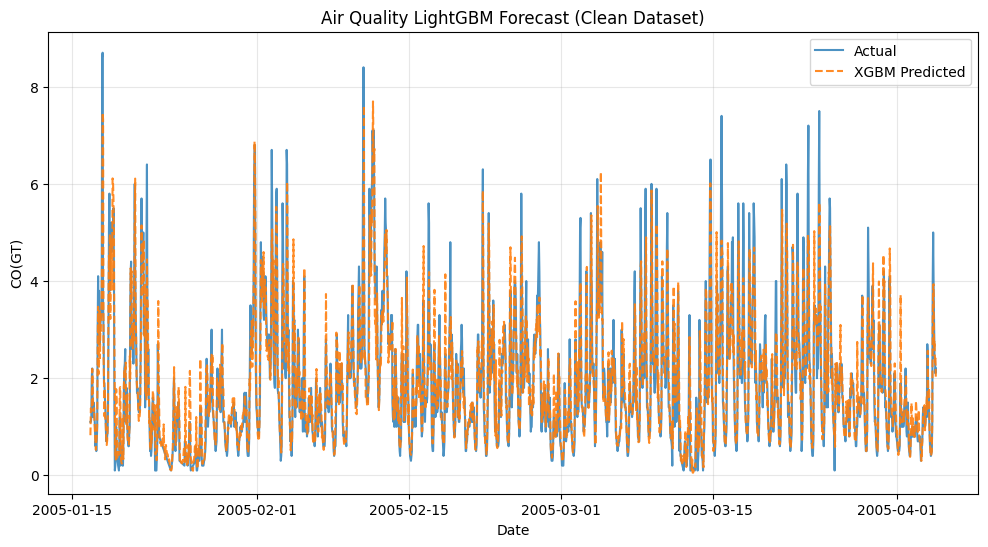

In [3]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# ==========================================
# 1. LOAD AND PARSE DATASET
# ==========================================
# Correctly load the Air Quality UCI dataset specifying separator and decimal
air_quality_df = pd.read_csv("/content/AirQualityUCI.csv", sep=";", decimal=",")

# Drop columns that are entirely NaN (often at the end of this dataset)
air_quality_df = air_quality_df.dropna(axis=1, how="all")
# Drop rows where 'Date' or 'Time' are missing
air_quality_df = air_quality_df.dropna(subset=["Date", "Time"])

# Combine 'Date' and 'Time' into a single Datetime index
air_quality_df["Datetime"] = pd.to_datetime(
    air_quality_df["Date"] + " " + air_quality_df["Time"],
    format="%d/%m/%Y %H.%M.%S",
)
air_quality_df = air_quality_df.set_index("Datetime").drop(
    columns=["Date", "Time"]
)

# Convert relevant columns to numeric. Coerce errors to NaN.
numeric_cols = [
    "CO(GT)",
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
]

for col in numeric_cols:
    if col in air_quality_df.columns:
        air_quality_df[col] = pd.to_numeric(
            air_quality_df[col], errors="coerce"
        )

# ==========================================
# 2. DATA CLEANING (Catching the -200 flags)
# ==========================================
# Replace the fake -200 values with NaN (Now that column is strictly numeric)
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].replace(-200, np.nan)

# Fill the gaps smoothly by connecting the last good point to the next good point
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].interpolate(
    method="linear"
)

# Clean up edge cases (if a -200 happened to be the very first or last row)
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].bfill().ffill()

# Drop rows that have NaN in the target column after conversion
target_column = "CO(GT)"
air_quality_df = air_quality_df.dropna(subset=[target_column])

# Ensure the index is sorted chronologically
air_quality_df = air_quality_df.sort_index()


# ==========================================
# 3. FEATURE ENGINEERING FOR LIGHTGBM
# ==========================================
df_lgb = air_quality_df.copy()

# Extract cyclical time features
df_lgb["Hour"] = df_lgb.index.hour
df_lgb["DayOfWeek"] = df_lgb.index.dayofweek

# Create Lag Features (adjust range to match your LSTM lookback window length)
for lag in range(1, 4):
    df_lgb[f"CO_lag_{lag}"] = df_lgb["CO(GT)"].shift(lag)

# Create a Rolling Mean feature to capture recent trajectory trends
df_lgb["CO_rolling_mean_3h"] = (
    df_lgb["CO(GT)"].shift(1).rolling(window=3).mean()
)

# Drop the edge boundary rows containing NaNs created by shifting/rolling
df_tabular = df_lgb.dropna()

# Select feature columns (excluding target or unrelated metrics)
feature_cols = [
    "Hour",
    "DayOfWeek",
    "CO_lag_1",
    "CO_lag_2",
    "CO_lag_3",
    "CO_rolling_mean_3h",
]
X = df_tabular[feature_cols]
y = df_tabular["CO(GT)"]


# ==========================================
# 4. CHRONOLOGICAL SPLIT, TRAINING & METRICS
# ==========================================
# Chronological split to preserve time-series ordering (e.g., 80% train, 20% test)
split_index = int(len(df_tabular) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Initialize and train the LightGBM Regressor using MAE objective
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

# Generate forecasts for your test window
predictions = model.predict(X_test)

# Calculate final tabular performance metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n--- MODEL METRICS ---")
print(f"XGB Test MAE : {mae:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")


# ==========================================
# 5. VISUALIZE LIGHTGBM RESULTS
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", color="tab:blue", alpha=0.8)
plt.plot(
    y_test.index,
    predictions,
    label="XGBM Predicted",
    color="tab:orange",
    linestyle="--",
    alpha=0.9,
)
plt.title("Air Quality LightGBM Forecast (Clean Dataset)")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()